# Klasifikasi Multi-Kelas Pesan SMS Spam Bahasa Indonesia Menggunakan Fine-Tuning IndoBERT dan XLM-RoBERTa

## A. Identitas Kelompok
* **Mata Kuliah:** SINF6054 - Pemrosesan Bahasa Alami (Kelas A)
* **Kelompok:** 14
* **Anggota Tim:**
    1. Tinsari Rauhana (2308107010038)
    2. Naufal Hanif (2308107010025)
    3. Haikal Aulia (2308107010063)

## B. Deskripsi Project
Project ini berfokus pada pengembangan sistem deteksi otomatis pesan SMS spam berbahasa Indonesia menggunakan pendekatan Natural Language Processing (NLP) berbasis model Transformer pretrained. Karakteristik bahasa SMS di Indonesia memiliki tantangan tersendiri karena bersifat informal, penuh singkatan, dan sering melibatkan campur kode (code-switching) antara bahasa Indonesia dan bahasa Inggris. Untuk mengatasi tantangan tersebut, project ini melakukan studi komparatif secara head-to-head antara model IndoBERT (sebagai representasi model monolingual yang memahami konteks lokal) dan XLM-ROBERTa (sebagai representasi model multilingual masif).

Pesan SMS akan diklasifikasikan ke dalam tiga kategori (multi-class), yaitu: Normal (pesan umum atau aman), Promo (penawaran produk atau iklan dari operator), dan Penipuan (pesan pancingan yang berpotensi merugikan pengguna secara finansial). Selain proses fine-tuning pada kedua arsitektur tersebut, project ini juga mengimplementasikan teknik class weighting pada fungsi loss untuk menangani masalah ketidakseimbangan data (class imbalance) yang umum ditemukan pada dataset sejenis.

## C. Informasi Penting Project

### 1. Spesifikasi Dataset
* **Nama Dataset:** Dataset Klasifikasi SMS Spam Bahasa Indonesia
* **Sumber Data:** Yudi Wibisono (yudiwbs) via https://yudiwbs.wordpress.com/2018/08/05/dataset-klasifikasi-bahasa-indonesia-sms-spam-klasifikasi-teks-dengan-scikit-learn/
* **Skema Target Label (3 Kelas):** 
    * 0: Normal
    * 1: Promo
    * 2: Penipuan

### 2. Arsitektur Model dan Eksperimen
* **Model Monolingual:** indobenchmark/indobert-base-p1 (IndoBERT Base)
* **Model Multilingual:** xlm-roberta-base (XLM-ROBERTa Base)
* **Metode Pelatihan:** Fine-tuning dengan optimasi CrossEntropyLoss menggunakan pendekatan Class Weighting.
* **Rasio Pembagian Data:** 70% Data Pelatihan (Training), 20% Data Validasi (Validation), dan 10% Data Pengujian (Testing) yang dibagi menggunakan metode Stratified Split.

### 3. Metrik Evaluasi
Perbandingan performa kedua model dilakukan secara komprehensif menggunakan metrik evaluasi standar sebagai berikut:
* Accuracy
* Precision
* Recall
* F1-Score (Macro dan Weighted)
* Confusion Matrix untuk analisis kesalahan prediksi per kelas

## 1. Data Preprocessing

Tahap preprocessing data dilakukan untuk membersihkan teks mentah dari noise serta menyelaraskan struktur data agar siap digunakan dalam proses pelatihan model Transformer. Berdasarkan karakteristik data SMS spam, tahapan pembersihan dan transformasi data yang diimplementasikan meliputi:

* **Pemuatan Data dan Penanganan Nilai Kosong**: Dataset dimuat dari file mentah untuk kemudian dilakukan penghapusan baris yang tidak memiliki kelengkapan informasi pada kolom teks maupun kolom label menggunakan fungsi dropna.
* **Pembersihan Link (URL)**: Menghapus seluruh link berbasis HTTP, HTTPS, maupun format WWW menggunakan regex karena informasi URL tidak memberikan kontribusi kontekstual pada klasifikasi pesan dan cenderung memicu overfitting.
* **Pembersihan Simbol Karakter Berlebih**: Mengganti karakter non-alfanumerik yang tidak relevan dengan spasi, serta mereduksi pengulangan karakter yang sama secara beruntun (lebih dari dua kali) menjadi maksimal dua kali pengulangan untuk menangani kata-kata ekspresif yang tidak baku.
* **Normalisasi Huruf Kecil (Case Folding)**: Mengubah seluruh karakter huruf di dalam teks menjadi huruf kecil (lowercase) untuk memastikan konsistensi pemrosesan dan menghindari duplikasi representasi kata akibat perbedaan kapitalisasi.
* **Normalisasi Spasi dan Karakter Kosong**: Menghapus spasi berlebih di awal, di akhir, maupun di tengah teks sehingga setiap kata hanya dipisahkan oleh satu karakter spasi tunggal.
* **Pemetaan dan Pembersihan Label**: Memetakan nilai label teks ke dalam format standar (normal, promo, penipuan) serta mengeliminasi baris data yang memiliki label di luar skema target tersebut.

Proses pembersihan ini berhasil memproses keseluruhan 1143 baris data tanpa ada data yang terbuang akibat nilai kosong. Hasil akhir dari tahap ini berupa dataset bersih dengan struktur kolom baru, yaitu text dan label, yang kemudian disimpan ke dalam format CSV untuk digunakan pada tahap pemodelan selanjutnya.

### 1.1 Impor Library dan Inisialisasi Konfigurasi Global

Bagian ini berfungsi untuk memuat seluruh library dasar, modul utilitas eksternal yang berada pada directory lokal, serta mendefinisikan variabel global. Konfigurasi ini mencakup path file data serta pemetaan label target untuk menjamin konsistensi alur kerja dari tahap preprocessing hingga analisis data eksploratif (EDA).

In [1]:
import os
import json
import pandas as pd
from pandas import DataFrame

# Mengimpor modul utilitas internal project untuk EDA, preprocessing, dan manipulasi data
from include.eda import EDA
from include.preprocessor import DataPreprocessor
from include.data_utils import split_dataset, compute_weights

In [2]:
# Mengonfigurasi path directory kerja untuk penyimpanan seluruh file data
DATA_DIR = os.path.join(os.getcwd(), "data")
os.makedirs(DATA_DIR, exist_ok = True)

# Menentukan path file input (mentah) dan file output (bersih)
RAW_PATH = os.path.join(DATA_DIR, "dataset.csv")
CLEANED_PATH = os.path.join(DATA_DIR, "preprocessed.csv")

# Kamus referensi untuk standardisasi variasi penulisan label target ke dalam tiga kelas utama
LABEL_MAP = {
    "normal" : "normal",
    "promo" : "promo",
    "penipuan" : "penipuan",
    "ham" : "normal",
    "spam" : "promo",
}

# Menentukan path penyimpanan untuk pembagian subset data dan bobot kelas
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
VAL_PATH = os.path.join(DATA_DIR, "val.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
CLASS_WEIGHTS_PATH = os.path.join(DATA_DIR, "class_weights.json")

### 1.2 Pemuatan dan Pemeriksaan Awal Dataset Mentah

Dataset mentah dimuat ke dalam objek DataFrame untuk dilakukan verifikasi struktural awal. Tahap ini bertujuan untuk memastikan kelengkapan file serta mengetahui dimensi awal data beserta kolom yang tersedia sebelum dilakukan manipulasi lebih lanjut.

In [3]:
# Memuat data teks mentah dengan format pemisah koma
df = pd.read_csv(RAW_PATH, header = 0, sep = ",")
df.head()

,Teks,label
0,[PROMO] Beli paket Flash mulai 1GB di MY TELKO...,promo
1,2.5 GB/30 hari hanya Rp 35 Ribu Spesial buat A...,promo
2,"2016-07-08 11:47:11.Plg Yth, sisa kuota Flash ...",promo
3,"2016-08-07 11:29:47.Plg Yth, sisa kuota Flash ...",promo
4,4.5GB/30 hari hanya Rp 55 Ribu Spesial buat an...,promo


In [4]:
# Menampilkan informasi ringkas dimensi awal dan struktur kolom dataset
print("Informasi Dataset")
print("Total baris    :", len(df))
print("Kolom tersedia :", list(df.columns))

Informasi Dataset
Total baris    : 1143
Kolom tersedia : ['Teks', 'label']


### 1.3 Eksekusi Fungsi Preprocessing Data

Pada tahap ini, objek dari modul eksternal DataPreprocessor diinisialisasi untuk membersihkan isi teks dan menyelaraskan label. Seluruh rangkaian proses pembersihan diintegrasikan ke dalam fungsi run_preprocessing untuk memfilter nilai kosong, melakukan normalisasi teks, menghilangkan noise, serta menampilkan ringkasan sebaran distribusi kelas akhir.

In [5]:
# Inisialisasi objek preprocessor dari modul eksternal yang diimpor
preprocessor = DataPreprocessor()

def run_preprocessing(df: DataFrame) -> DataFrame:
    COL_TEXT = "Teks"
    COL_LABEL = "label"
    
    temp_df = df.copy()
    
    # Validasi awal untuk memastikan keberadaan kolom teks dan label pada DataFrame
    if COL_TEXT not in temp_df.columns or COL_LABEL not in temp_df.columns:
        print(f"Kolom '{COL_TEXT}' dan '{COL_LABEL}' tidak ditemukan")
        return
    
    # Tahap 1: Eliminasi baris data yang mengandung nilai kosong (missing values)
    df_len = len(temp_df)
    temp_df = temp_df[[COL_TEXT, COL_LABEL]].dropna()
    print(f"[dropna: {COL_TEXT}, {COL_LABEL}] {df_len - len(temp_df)} baris data dihapus")
    df_len = len(temp_df)
    
    # Tahap 2: Transformasi dan penyelarasan nilai label berdasarkan LABEL_MAP
    temp_df["label_clean"] = temp_df[COL_LABEL].apply(
        lambda label: preprocessor._normalize_label(LABEL_MAP, label)
    )
    temp_df = temp_df.dropna(subset = ["label_clean"])
    print(f"[dropna: label_clean] {df_len - len(temp_df)} baris data dihapus")
    
    # Tahap 3: Pembersihan konten teks dan penyaringan teks kosong setelah pembersihan
    temp_df["text_clean"] = temp_df[COL_TEXT].apply(preprocessor.preprocess_text)
    temp_df = temp_df[temp_df["text_clean"].str.len() > 0]
    
    # Mengembalikan DataFrame baru dengan struktur kolom yang telah disesuaikan
    return temp_df[["text_clean", "label_clean"]].rename(
        columns = {
            "text_clean": "text", 
            "label_clean": "label"
        }
    )
    
# Menjalankan fungsi utama preprocessing data
clean_df = run_preprocessing(df)

# Menampilkan informasi ringkas statistik dataset setelah pembersihan beserta sebaran kelasnya
print("\nInformasi Dataset (Cleaned)")
print("Total data      :", len(clean_df))
print("Kolom tersedia  :", list(df.columns))
print("Distribusi data :")
print(clean_df["label"].value_counts().to_string())

clean_df.head()

[dropna: Teks, label] 0 baris data dihapus
[dropna: label_clean] 0 baris data dihapus

Informasi Dataset (Cleaned)
Total data      : 1143
Kolom tersedia  : ['Teks', 'label']
Distribusi data :
label
normal      569
penipuan    335
promo       239


,text,label
0,promo beli paket flash mulai 1gb di my telkoms...,promo
1,2.5 gb 30 hari hanya rp 35 ribu spesial buat a...,promo
2,"2016 07 08 11 47 11.plg yth, sisa kuota flash ...",promo
3,"2016 08 07 11 29 47.plg yth, sisa kuota flash ...",promo
4,4.5gb 30 hari hanya rp 55 ribu spesial buat an...,promo


### 1.4 Penyimpanan File Hasil Preprocessing

Dataset yang telah dibersihkan secara menyeluruh kemudian disimpan ke dalam format penyimpanan sekunder. Proses penyimpanan ini menggunakan encoding standar guna menjamin integritas karakter teks saat dimuat kembali pada tahapan pemodelan.

In [6]:
clean_df.to_csv(CLEANED_PATH, index = False, encoding = "utf-8")
print("File dataset disimpan di:", CLEANED_PATH)

File dataset disimpan di: d:\College\NLP\UAS\Kelompok14_FinalNLP_A\data\preprocessed.csv


## 2. Dataset Splitting dan Perhitungan Class Weight

Tahap ini berfokus pada pembagian data ke dalam tiga subset utama, yaitu training, validation, dan testing, serta perhitungan bobot kelas. Pembagian data dilakukan untuk memastikan model dapat dilatih, divalidasi, dan diuji menggunakan data yang independen. Perhitungan bobot kelas ditujukan untuk memitigasi dampak dari ketidakseimbangan jumlah sampel antar-label pada fungsi loss saat proses fine-tuning model Transformer dilakukan.

### 2.1 Konfigurasi Parameter dan Pemuatan Data Bersih

Sebelum pembagian data dieksekusi, parameter rasio pembagian didefinisikan secara eksplisit bersama dengan random state untuk menjamin reproduksibilitas eksperimen. Sistem akan memeriksa keberadaan DataFrame hasil preprocessing di memori lokal atau memuatnya kembali dari file CSV bersih yang telah disimpan sebelumnya.

In [7]:
# Menentukan proporsi pembagian data untuk subset training, validation, dan testing
TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10
RANDOM_STATE = 42

# Memuat data dari variabel lokal clean_df atau membaca dari file preprocessed.csv jika data di memori kosong
df = clean_df if "clean_df" in locals() else pd.read_csv(CLEANED_PATH, header = 0, sep = ",")
df.head()

,text,label
0,promo beli paket flash mulai 1gb di my telkoms...,promo
1,2.5 gb 30 hari hanya rp 35 ribu spesial buat a...,promo
2,"2016 07 08 11 47 11.plg yth, sisa kuota flash ...",promo
3,"2016 08 07 11 29 47.plg yth, sisa kuota flash ...",promo
4,4.5gb 30 hari hanya rp 55 ribu spesial buat an...,promo


### 2.2 Pembagian Dataset dan Analisis Distribusi Label

Fungsi split_dataset dipanggil untuk membagi data secara proporsional sesuai rasio yang dikonfigurasi. Untuk membuktikan efektivitas metode stratified sampling, sistem melakukan perulangan (looping) untuk memeriksa persentase dan distribusi sebaran kelas pada masing-masing subset data hasil pembagian.

In [8]:
# Membagi dataset menjadi tiga komponen subset menggunakan fungsi utilitas dengan metode stratified sampling
df_train, df_val, df_test = split_dataset(
    df, 
    label = "label", 
    train_ratio = TRAIN_RATIO, 
    val_ratio = VAL_RATIO, 
    test_ratio = TEST_RATIO
)

# Menampilkan output ringkasan total baris data dan persentase untuk masing-masing subset
print("Informasi Dataset (Train, Val, Test)")
print(f"Train : {len(df_train)} baris ({len(df_train) / len(df) * 100:.1f}%)")
print(f"Val   : {len(df_val)} baris ({len(df_val) / len(df) * 100:.1f}%)")
print(f"Test  : {len(df_test)} baris ({len(df_test) / len(df) * 100:.1f}%)")

Informasi Dataset (Train, Val, Test)
Train : 799 baris (69.9%)
Val   : 229 baris (20.0%)
Test  : 115 baris (10.1%)


In [9]:
# Melakukan iterasi untuk menampilkan verifikasi sebaran distribusi kelas di setiap subset data
for nama, subset in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    dist = subset["label"].value_counts()
    print(f"\nDistribusi Label ({nama})")
    
    for label, count in dist.items():
        # Memastikan format cetak rata kiri agar informasi jumlah sampel dan persentase tersusun rapi
        print(f"{label:<10}: {count} ({count/len(subset)*100:.1f}%)")


Distribusi Label (Train)
normal    : 398 (49.8%)
penipuan  : 234 (29.3%)
promo     : 167 (20.9%)

Distribusi Label (Val)
normal    : 114 (49.8%)
penipuan  : 67 (29.3%)
promo     : 48 (21.0%)

Distribusi Label (Test)
normal    : 57 (49.6%)
penipuan  : 34 (29.6%)
promo     : 24 (20.9%)


### 2.3 Penyimpanan Subset Data ke File CSV

Setelah proses pembagian dan verifikasi selesai, ketiga subset data (train, val, dan test) diekspor ke dalam file CSV terpisah pada directory penyimpanan data agar dapat dimuat secara instan pada tahapan tokenisasi dan pemodelan berikutnya.

In [10]:
# Menyimpan masing-masing subset data ke dalam path yang telah ditentukan dalam bentuk file CSV independen
df_train.to_csv(TRAIN_PATH, index = False, encoding = "utf-8")
df_val.to_csv(VAL_PATH, index = False, encoding = "utf-8")
df_test.to_csv(TEST_PATH, index = False, encoding = "utf-8")

print("File dataset (Train, Val, Test) disimpan di:")
print("Train :", TRAIN_PATH)
print("Val   :", VAL_PATH)
print("Test  :", TEST_PATH)

File dataset (Train, Val, Test) disimpan di:
Train : d:\College\NLP\UAS\Kelompok14_FinalNLP_A\data\train.csv
Val   : d:\College\NLP\UAS\Kelompok14_FinalNLP_A\data\val.csv
Test  : d:\College\NLP\UAS\Kelompok14_FinalNLP_A\data\test.csv


### 2.4 Perhitungan dan Persistensi Class Weight

Akibat adanya ketidakseimbangan data yang signifikan pada subset training (kelas normal mendominasi hampir 50%), kalkulasi bobot kelas dilakukan menggunakan fungsi compute_weights yang berbasis pada data training saja. Nilai bobot ini disimpan ke dalam file JSON eksternal dan akan diintegrasikan dengan CrossEntropyLoss sebagai penalti proporsional bagi model saat melakukan kesalahan prediksi pada kelas minoritas.

In [11]:
# Menghitung bobot kelas menggunakan data training untuk menghindari data leakage dari data val atau test
weight_dict = compute_weights(df_train, label = "label")

# Menyimpan dictionary bobot kelas ke dalam file berkstensi JSON dengan konfigurasi indentasi agar mudah dibaca
with open(CLASS_WEIGHTS_PATH, "w") as file:
    json.dump(weight_dict, file, indent = 4)
    
print("File JSON class weight disimpan di:", CLASS_WEIGHTS_PATH)

File JSON class weight disimpan di: d:\College\NLP\UAS\Kelompok14_FinalNLP_A\data\class_weights.json


In [12]:
print("Class Weight (CrossEntropyLoss)")

# Menampilkan nilai bobot akhir untuk tiap kelas dengan presisi empat angka di belakang koma
for label, weight in weight_dict.items():
    print(f"{label:<10}: {weight:.4f}")

Class Weight (CrossEntropyLoss)
normal    : 0.6692
penipuan  : 1.1382
promo     : 1.5948


## 3. Exploratory Data Analysis (EDA) dan Visualisasi Data

Tahap ini bertujuan untuk mengeksplorasi karakteristik internal dataset yang telah dibersihkan melalui pendekatan statistik deskriptif dan visualisasi grafik. Analisis data eksploratif ini berfokus pada pemahaman sebaran distribusi kelas, identifikasi anomali data (seperti duplikasi teks), serta analisis komparasi struktur panjang pesan SMS pada tiap-tiap kelompok label target guna memperoleh wawasan kontekstual sebelum melangkah ke tahap training model.

### 3.1 Inisialisasi Objek EDA dan Konfigurasi Warna Grafik

Proses analisis diawali dengan menentukan pemetaan warna palet visualisasi yang konsisten untuk setiap kelas target (normal, promo, dan penipuan). Setelah palet warna dikonfigurasi, objek utilitas analisis diinstansiasi dari modul eksternal EDA.

In [13]:
# Konfigurasi kode warna hex standar yang representatif untuk membedakan kategori teks pada visualisasi plot
LABEL_COLORS = {
    "normal" : "#4C72B0",
    "promo" : "#DD8452",
    "penipuan" : "#C44E52",
}

# Inisialisasi objek modul analisis data eksploratif dengan menyertakan konfigurasi peta warna
eda = EDA(LABEL_COLORS)

### 3.2 Analisis Distribusi Kelas dan Karakteristik Panjang Teks

Fungsi kalkulasi dipanggil untuk menghitung distribusi frekuensi sampel dan nilai persentase proporsi data pada masing-masing kelompok kelas. Selain itu, dilakukan kalkulasi data statistik deskriptif berupa nilai minimum, maksimum, rata-rata (mean), dan nilai tengah (median) untuk melacak pola struktur panjang karakter dan jumlah kata yang menyusun pesan SMS.

In [14]:
# Menghitung metrik sebaran distribusi jumlah data dan persentase untuk tiap label target
dist = eda.analyze_label_distribution(df)
print("Distribusi label:")
print(dist.to_string(index = False))

Distribusi label:
   label  jumlah  persentase
  normal     569       49.78
penipuan     335       29.31
   promo     239       20.91


In [15]:
# Eksekusi fungsi kalkulasi untuk memuat statistik deskriptif panjang pesan SMS
df_len, stats_len = eda.analyze_text_length(df)
print("Statistik panjang teks per label:")
print(stats_len.to_string())

Statistik panjang teks per label:
         panjang_karakter                    jumlah_kata                 
                      min  max   mean median         min max  mean median
label                                                                    
normal                 13  432   69.7   58.0           2  63  12.2   10.0
penipuan               46  391  132.9  125.0           8  62  22.2   21.0
promo                  48  306  133.8  134.0           8  60  22.8   23.0


### 3.3 Deteksi Data Duplikat dan Validasi Teks Sangat Pendek

Tahap filtering ini dilakukan untuk memastikan kualitas integritas data sebelum proses tokenisasi model Transformer. Sistem akan memindai keberadaan teks duplikat pada korpus data serta mendeteksi adanya teks anomali yang terlalu pendek (di bawah ambang batas lima karakter) yang berpotensi tidak memiliki nilai informasi kontekstual yang berarti.

In [16]:
# Memeriksa total kemunculan baris data duplikat yang memiliki isi string teks yang sama persis
duplicate = df.duplicated(subset = ["text"]).sum()
print(f"Jumlah teks duplikat: {duplicate} data")

Jumlah teks duplikat: 4 data


In [17]:
# Mendeteksi total baris data yang memiliki panjang karakter sangat pendek di bawah nilai ambang batas lima karakter
shortest_text = (df["text"].str.len() < 5).sum()
print(f"Teks sangat pendek (<5 karakter): {shortest_text} data")

Teks sangat pendek (<5 karakter): 0 data


### 3.4 Visualisasi Komparatif Distribusi dan Karakteristik Dataset

Bagian ini memanggil rangkaian fungsi visualisasi grafik untuk menyajikan temuan statistik secara visual. Proses visualisasi mencakup pembuatan grafik batang dan lingkaran untuk memetakan imbalance ratio data kelas, histogram untuk menampilkan frekuensi sebaran panjang teks, serta boxplot untuk mengidentifikasi keberadaan outlier data panjang karakter maupun kata pada masing-masing label target.

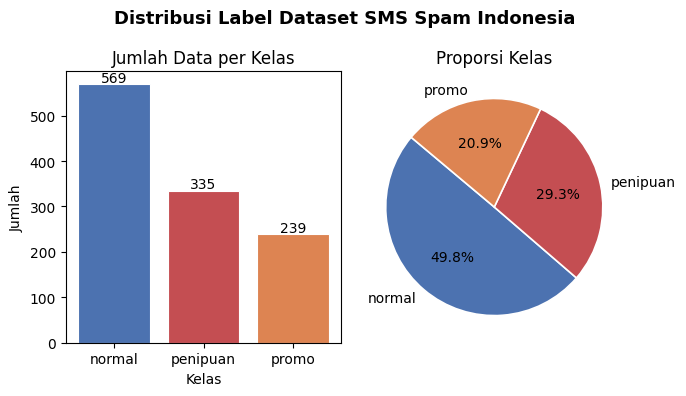

In [18]:
# Menampilkan grafik komparasi berupa bar chart dan pie chart untuk proporsi sebaran label target
eda.plot_label_distribution(dist)

**Interpretasi:**

Berdasarkan visualisasi distribusi label dataset SMS spam Indonesia, dapat dilihat bahwa terdapat ketidakseimbangan kelas (*class imbalance*) yang cukup signifikan di dalam dataset. Kelas *normal* mendominasi dengan jumlah sampel terbanyak, yaitu mencapai 569 data atau mencakup sekitar 49.8% dari total keseluruhan dataset. Sementara itu, kategori pesan *penipuan* menempati posisi kedua dengan jumlah data sebanyak 335 sampel (29.3%), diikuti oleh kategori pesan *promo* sebagai kelas minoritas dengan jumlah data paling sedikit, yaitu sebesar 239 sampel atau setara dengan 20.9% dari total data. Ketidakseimbangan proporsi ini mendasari keputusan teknis dalam metodologi proyek untuk menerapkan pendekatan *class weighting* pada fungsi *loss* saat proses pelatihan model transformer dilakukan guna mencegah bias prediksi.

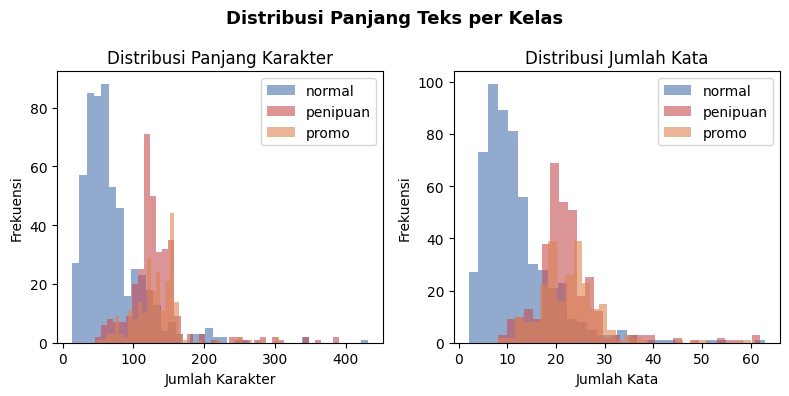

In [19]:
# Menampilkan grafik histogram untuk visualisasi tren persebaran kuantitas karakter dan jumlah kata
eda.plot_text_length(df_len)

**Interpretasi:** 

Melalui grafik distribusi panjang teks per kelas, terlihat adanya perbedaan karakteristik pola penulisan yang kontras antara pesan SMS berkategori *normal* dengan pesan berkategori *spam* (*promo* dan *penipuan*). Pesan berkategori *normal* cenderung memiliki distribusi yang berpusat pada panjang teks yang jauh lebih pendek, dengan puncak frekuensi berada pada kisaran di bawah 100 karakter atau kurang dari 15 kata. Sebaliknya, pesan berkategori *penipuan* dan *promo* menunjukkan grafik sebaran yang bergeser ke arah kanan, yang menandakan bahwa pesan jenis ini ditulis secara lebih panjang dan bertele-tele, di mana konsentrasi frekuensi tertingginya berada pada rentang antara 100 hingga 150 karakter atau sekitar 15 sampai 30 kata. Karakteristik struktural panjang dokumen teks ini dapat menjadi fitur kontekstual yang kuat bagi model bahasa dalam membedakan pesan teks organik dengan pesan teks massal.

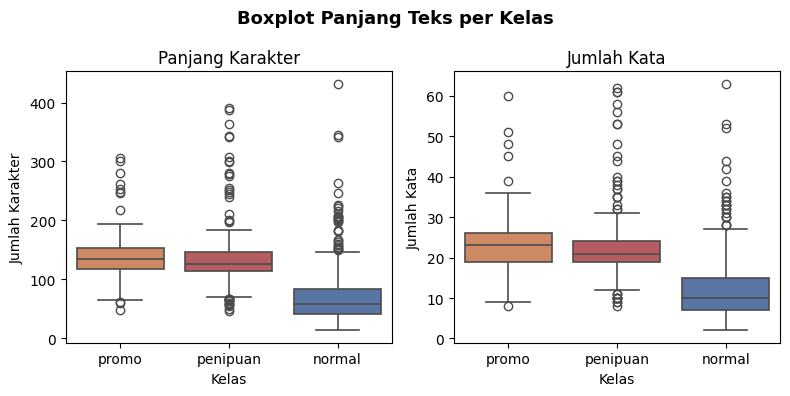

In [20]:
# Menampilkan grafik boxplot untuk pemetaan dispersi data statistik serta deteksi outlier teks per kelas
eda.plot_boxplot_length(df_len)

**Interpretasi:** 

Visualisasi menggunakan grafik *boxplot* mempertegas analisis variasi sebaran nilai statistik serta mengidentifikasi keberadaan pencilan data (*outlier*) panjang teks pada setiap kelas target. Kelas *promo* dan *penipuan* menunjukkan letak kotak (*interquartile range*) dan garis nilai tengah (median) yang sejajar dan jauh lebih tinggi daripada kelas *normal*, baik pada metrik jumlah karakter maupun jumlah kata. Hal ini mengonfirmasi secara konsisten bahwa pesan promosi dan penipuan secara umum memiliki struktur kalimat yang padat dan panjang. Selain itu, grafik *boxplot* ini mendeteksi kemunculan sejumlah titik *outlier* di sisi atas pada ketiga kelas label, terutama pada kelas *normal* yang memiliki beberapa data dengan panjang karakter ekstrim hingga melebihi angka 300 sampai 400 karakter, yang menunjukkan adanya anomali pesan personal yang ditulis jauh lebih panjang dari rata-rata pesan normal lainnya.

## 4. Model Training dan Fine-Tuning IndoBERT

Tahap ini berfokus pada implementasi proses fine-tuning pre-trained model IndoBERT (`indobenchmark/indobert-base-p1`) untuk tugas klasifikasi teks multi-kelas. Alur kerja mencakup penyiapan library, definisi hyperparameter, pemuatan data ke dalam format PyTorch tensor, hingga eksekusi loop pelatihan dan evaluasi performa model menggunakan metrik klasifikasi standar.

### 4.1 Impor Library dan Konfigurasi Hyperparameter Global

Langkah awal diisi dengan memuat library utama seperti PyTorch, Transformers dari Hugging Face, dan Scikit-Learn. Untuk menjaga konsistensi perbandingan, parameter global serta directory penyimpanan model untuk IndoBERT maupun XLM-RoBERTa didefinisikan secara tersentralisasi pada bagian ini.

In [21]:
import os
import json
import numpy as np
import pandas as pd
import torch

# Memeriksa versi PyTorch dan ketersediaan hardware akselerasi GPU CUDA
print("Torch version        :", torch.__version__)
print("Torch CUDA avaliable :", torch.cuda.is_available())

from include.helper import TrainHelper
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import classification_report, accuracy_score
from include.dataset import SMSDataset

Torch version        : 2.6.0+cu124
Torch CUDA avaliable : True


d:\College\NLP\UAS\Kelompok14_FinalNLP_A\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# Definisi directory penyimpanan model lokal hasil fine-tuning
MODEL_DIR = os.path.join(os.getcwd(), "model")
os.makedirs(MODEL_DIR, exist_ok = True)

INDOBERT_DIR = os.path.join(MODEL_DIR, "indobert")
os.makedirs(INDOBERT_DIR, exist_ok = True)
INDOBERT_MODEL_NAME = "indobenchmark/indobert-base-p1"

XLM_ROBERTA_DIR = os.path.join(MODEL_DIR, "xlm_roberta")
os.makedirs(XLM_ROBERTA_DIR, exist_ok = True)
XLM_ROBERTA_MODEL_NAME = "FacebookAI/xlm-roberta-base"

# Konfigurasi parameter pelatihan utama untuk arsitektur Transformer
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
WEIGHT_DECAY = 0.01
RANDOM_STATE = 42

# Definisi dictionary pemetaan teks kategori ke index bilangan bulat (integer)
LABEL2ID = {
    "normal": 0, 
    "promo": 1, 
    "penipuan": 2
}
ID2LABEL = {value: key for key, value in LABEL2ID.items()}

### 4.2 Alokasi Komputasi Hardware dan Pemuatan Nilai Bobot Kelas

Proses dilanjutkan dengan mengunci seed random variabel demi aspek reproducible research, mengatur alokasi pemrosesan pada perangkat GPU CUDA, serta memuat file bobot kelas (*class weights*). Bobot ini dikonversi menjadi bentuk tensor untuk disuntikkan ke dalam fungsi loss sebagai penanganan ketidakseimbangan data.

In [23]:
# Mengunci seed nilai acak untuk PyTorch dan NumPy agar hasil pengujian tetap konsisten
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Mengarahkan komputasi secara otomatis ke GPU jika tersedia, atau CPU sebagai cadangan
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)
df_test = pd.read_csv(TEST_PATH)

print("Informasi Dataset")
print(f"Train : {len(df_train)} data")
print(f"Val   : {len(df_val)} data")
print(f"Test  : {len(df_test)} data")

Device: cuda
Informasi Dataset
Train : 799 data
Val   : 229 data
Test  : 115 data


In [24]:
# Memuat konfigurasi class weights hasil kalkulasi tahap sebelumnya untuk disalin ke memori GPU
with open(CLASS_WEIGHTS_PATH) as file:
    weights_dict = json.load(file)
    
weights_tensor = torch.tensor(
    [weights_dict[ID2LABEL[index]] for index in range(len(ID2LABEL))],
    dtype = torch.float
).to(device)

print(f"Class weights: {weights_dict}")

helper = TrainHelper(ID2LABEL)

Class weights: {'normal': 0.669179229480737, 'penipuan': 1.1381766381766383, 'promo': 1.594810379241517}


### 4.3 Inisialisasi Arsitektur Model, Tokenizer, dan Data Loader

Objek tokenizer dan model sequence classification dimuat langsung dari Hugging Face Hub dengan menyelaraskan konfigurasi struktur dimensi target output kelas. Data teks kemudian dibungkus ke dalam objek `SMSDataset` dan didistribusikan ke dalam beberapa batch kelompok kecil menggunakan `DataLoader`.

In [25]:
# Mengunduh objek tokenizer resmi yang sesuai dengan pre-trained model IndoBERT
indobert_tokenizer = AutoTokenizer.from_pretrained(INDOBERT_MODEL_NAME)

# Inisialisasi arsitektur IndoBERT untuk Sequence Classification dengan penyesuaian skema label custom
indobert_model = AutoModelForSequenceClassification.from_pretrained(
    INDOBERT_MODEL_NAME,
    num_labels = len(LABEL2ID),
    id2label = ID2LABEL,
    label2id = LABEL2ID,
).to(device)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 20910.05it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
# Enkapsulasi dataset ke dalam subclass PyTorch Dataset
indobert_train_dataset = SMSDataset(LABEL2ID, df_train, indobert_tokenizer, MAX_LEN)
indobert_val_dataset = SMSDataset(LABEL2ID, df_val, indobert_tokenizer, MAX_LEN)
indobert_test_dataset = SMSDataset(LABEL2ID, df_test, indobert_tokenizer, MAX_LEN)

# Membuat komponen DataLoader untuk manajemen aliran iterasi batch data teks
indobert_train_loader = DataLoader(indobert_train_dataset, batch_size = BATCH_SIZE, shuffle = True)
indobert_val_loader = DataLoader(indobert_val_dataset, batch_size = BATCH_SIZE)
indobert_test_loader = DataLoader(indobert_test_dataset, batch_size = BATCH_SIZE)

### 4.4 Konfigurasi Optimizer, Fungsi Loss, dan Penjadwal Learning Rate

Proses optimasi dilangsungkan menggunakan algoritma AdamW dengan mengimplementasikan regularisasi weight decay. Pengaturan kurva learning rate ditangani oleh linear scheduler disertai fitur warmup, sedangkan kriteria evaluasi error dikalkulasi lewat CrossEntropyLoss berbasis bobot kelas penyeimbang.

In [27]:
# Inisialisasi komponen optimizer AdamW dengan parameter learning rate dan weight decay
indobert_optimizer = AdamW(indobert_model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)
indobert_total_steps = len(indobert_train_loader) * EPOCHS

# Mengatur mekanisme linear learning rate scheduler disertai tahapan warmup sebesar 10% dari total iterasi
indobert_scheduler = get_linear_schedule_with_warmup(
    indobert_optimizer,
    num_warmup_steps = int(0.1 * indobert_total_steps),
    num_training_steps = indobert_total_steps,
)

# Mendefinisikan fungsi loss Cross Entropy yang terintegrasi dengan bobot penyeimbang kelas target
criterion = torch.nn.CrossEntropyLoss(weight = weights_tensor)

### 4.5 Eksekusi Proses Pelatihan (*Fine-Tuning Loop*)

Iterasi pelatihan dijalankan sebanyak 3 epoch penuh. Pada setiap akhir tahapan epoch, sistem secara berkala akan menguji performa model ke data validasi. Jika didapatkan penurunan nilai validasi loss terendah yang baru (*best val loss*), bobot parameter model dan tokenizer akan langsung disimpan secara lokal ke dalam directory target. Model terbaik kemudian diekspor ke dalam format ONNX.

In [28]:
indobert_history = {
    "train_loss": [], 
    "val_loss": [], 
    "train_acc": [], 
    "val_acc": []
}
best_val_loss = float("inf")

# Melakukan looping proses training dan validasi untuk setiap siklus epoch
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = helper.train_epoch(indobert_model, indobert_train_loader, indobert_optimizer, indobert_scheduler, criterion, device)
    val_loss, val_acc = helper.eval_epoch(indobert_model, indobert_val_loader, criterion, device)

    indobert_history["train_loss"].append(train_loss)
    indobert_history["val_loss"].append(val_loss)
    indobert_history["train_acc"].append(train_acc)
    indobert_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} |",
        f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} |",
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
    )
    
    # Menerapkan skema checkpointing untuk mengamankan bobot parameter model terbaik berdasarkan performa val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        
        indobert_model.save_pretrained(INDOBERT_DIR)
        indobert_tokenizer.save_pretrained(INDOBERT_DIR)
        
        print(f"Model terbaik IndoBERT disimpan (val_loss: {val_loss:.4f})")

# Melakukan export model terbaik hasil pelatihan ke format ONNX    
onnx_export_path = os.path.join(INDOBERT_DIR, "model.onnx")
helper.export_to_onnx(
    indobert_model, 
    indobert_tokenizer, 
    onnx_export_path, 
    MAX_LEN, 
    device
)

Epoch 1/3 | Train Loss: 0.4722, Acc: 0.8360 | Val Loss: 0.1028, Acc: 0.9825


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.75it/s]


Model terbaik IndoBERT disimpan (val_loss: 0.1028)
Epoch 2/3 | Train Loss: 0.1499, Acc: 0.9625 | Val Loss: 0.1098, Acc: 0.9782
Epoch 3/3 | Train Loss: 0.0722, Acc: 0.9825 | Val Loss: 0.0781, Acc: 0.9869


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s]
d:\College\NLP\UAS\Kelompok14_FinalNLP_A\.venv\lib\site-packages\transformers\masking_utils.py:208: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if (padding_length := kv_length + kv_offset - attention_mask.shape[-1]) > 0:
d:\College\NLP\UAS\Kelompok14_FinalNLP_A\.venv\lib\site-packages\transformers\integrations\sdpa_attention.py:77: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  is_causal = query.shape[2] > 1 and attention_mask is None and is_causal


Model terbaik IndoBERT disimpan (val_loss: 0.0781)


d:\College\NLP\UAS\Kelompok14_FinalNLP_A\.venv\lib\site-packages\torch\onnx\symbolic_opset9.py:5383: UserWarning: Exporting aten::index operator of advanced indexing in opset 14 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


Model berhasil dikonversi ke format ONNX dan disimpan di: d:\College\NLP\UAS\Kelompok14_FinalNLP_A\model\indobert\model.onnx


### 4.6 Evaluasi Akhir Model pada Korpus Data Pengujian (*Test Dataset*)

Setelah rangkaian siklus fine-tuning selesai, checkpoint model IndoBERT terbaik dimuat kembali untuk dievaluasi secara objektif menggunakan subset data pengujian (*test dataset*) yang belum pernah dilihat sebelumnya oleh sistem. Evaluasi akhir ini memaparkan laporan klasifikasi lengkap serta visualisasi visual performa model.

In [29]:
# Memuat kembali parameter bobot pre-trained optimal hasil proses checkpointing sebelumnya
indobert_model = AutoModelForSequenceClassification.from_pretrained(INDOBERT_DIR).to(device)
all_labels, all_preds = helper.evaluate_test(indobert_model, indobert_test_loader, device)

label_names = [ID2LABEL[index] for index in range(len(ID2LABEL))]

# Menampilkan laporan metrik klasifikasi (precision, recall, f1-score) secara komprehensif
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names = label_names))

print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
classification_report(
    all_labels, 
    all_preds, 
    target_names = label_names, 
    output_dict = True
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9506.93it/s]


Classification Report:
              precision    recall  f1-score   support

      normal       0.98      1.00      0.99        57
       promo       0.88      0.96      0.92        24
    penipuan       0.97      0.88      0.92        34

    accuracy                           0.96       115
   macro avg       0.95      0.95      0.94       115
weighted avg       0.96      0.96      0.96       115

Accuracy: 0.9565


{'normal': {'precision': 0.9827586206896551,
  'recall': 1.0,
  'f1-score': 0.991304347826087,
  'support': 57.0},
 'promo': {'precision': 0.8846153846153846,
  'recall': 0.9583333333333334,
  'f1-score': 0.92,
  'support': 24.0},
 'penipuan': {'precision': 0.967741935483871,
  'recall': 0.8823529411764706,
  'f1-score': 0.9230769230769231,
  'support': 34.0},
 'accuracy': 0.9565217391304348,
 'macro avg': {'precision': 0.9450386469296369,
  'recall': 0.9468954248366014,
  'f1-score': 0.94479375696767,
  'support': 115.0},
 'weighted avg': {'precision': 0.9578368384046191,
  'recall': 0.9565217391304348,
  'f1-score': 0.9562518540061073,
  'support': 115.0}}

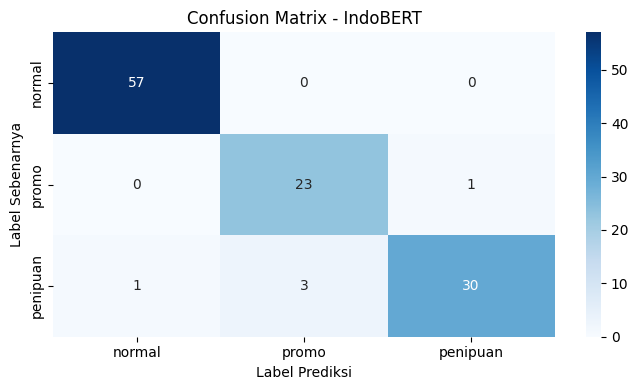

In [30]:
# Membuka fungsi plotting untuk menampilkan grafik confusion matrix prediksi
helper.plot_confusion_matrix(all_labels, all_preds, name = "IndoBERT")

**Interpretasi:** 

Berdasarkan visualisasi confusion matrix untuk model IndoBERT, performa klasifikasi yang dihasilkan menunjukkan tingkat akurasi yang sangat tinggi di seluruh kelas target. Pada kategori kelas `normal`, model berhasil memprediksi seluruh 57 sampel data uji secara sempurna tanpa adanya kesalahan klasifikasi (false positive maupun false negative). Untuk kategori kelas `promo`, dari total 24 data aktual, model sukses menebak 23 sampel dengan benar dan hanya mengalami 1 kesalahan prediksi yang tergolong ke dalam kelas `penipuan`. Sementara itu, pada kategori kelas `penipuan` yang berjumlah 34 sampel data aktual, model berhasil mengklasifikasikan 30 data secara tepat, meskipun masih terdapat sedikit error sebaran di mana 1 sampel terprediksi sebagai kelas `normal` dan 3 sampel lainnya keliru diklasifikasikan sebagai pesan `promo`.

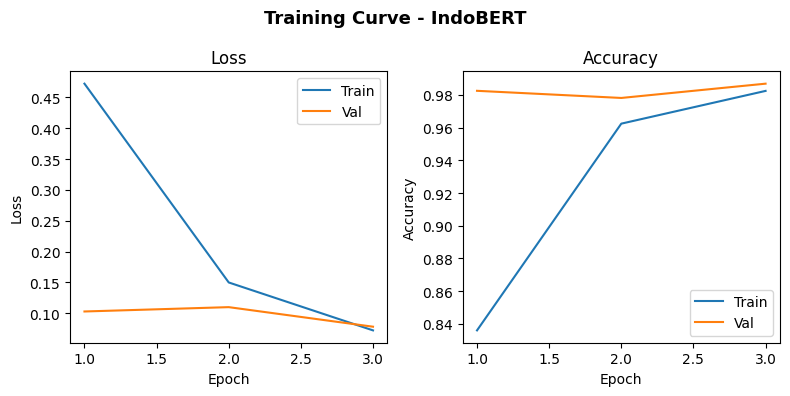

In [31]:
# Membuka fungsi plotting untuk menampilkan grafik kurva dinamika loss dan akurasi model
helper.plot_training_curve(indobert_history, name = "IndoBERT")

**Interpretasi:** 

Berdasarkan visualisasi kurva pelatihan (training curve) model IndoBERT, grafik pergerakan loss dan akurasi menunjukkan pola konvergensi yang sangat baik di setiap pergantian epoch. Pada grafik kurva loss, nilai error untuk data training mengalami penurunan yang sangat signifikan dan tajam, dimulai dari angka mendekati 0.47 pada epoch pertama hingga menyentuh nilai di bawah 0.10 pada akhir epoch ketiga. Penurunan ini diiringi oleh kestabilan kurva validasi loss yang secara konsisten bergerak melandai di rentang nilai rendah yang sama, yang mengindikasikan bahwa model tidak mengalami gejala overfitting. Selaras dengan penurunan tingkat error tersebut, kurva akurasi memperlihatkan lonjakan performa yang drastis pada data training dari semula berkisar di angka 0.84 meningkat pesat hingga melampaui 0.98, sementara akurasi pada data validasi tetap bertahan stabil dan konsisten berada di batas atas performa optimal sejak epoch awal.

## 5. Model Training dan Fine-Tuning XLM-RoBERTa

Tahap ini berfokus pada implementasi proses fine-tuning cross-lingual pre-trained model XLM-RoBERTa (`xlm-roberta-base`) untuk tugas klasifikasi teks multi-kelas pada korpus SMS. Alur kerja mencakup inisialisasi arsitektur tokenisasi berbasis SentencePiece, rekonstruksi pipeline input data menggunakan DataLoader baru, konfigurasi modul optimasi adaptif, hingga eksekusi loop pelatihan yang terintegrasi dengan skema checkpointing otomatis serta konversi biner grafik model ke format ONNX untuk kebutuhan deployment.

### 5.1 Inisialisasi Model dan Tokenizer XLM-RoBERTa

Proses awal pada bab ini adalah memuat komponen pre-trained tokenizer dan arsitektur model `xlm-roberta-base` melalui library Hugging Face Transformers. Karena XLM-RoBERTa dikembangkan dengan arsitektur tokenizer berbasis SentencePiece yang berbeda dari WordPiece milik IndoBERT, komponen ini harus diinisialisasi secara mandiri dari awal. Model dikonfigurasi untuk menangani jumlah kelas target yang sesuai dengan isi dictionary `LABEL2ID` dan seluruh parameter bobotnya langsung dialokasikan ke dalam memori hardware akselerasi (`device`).

In [32]:
# Definisi model name dan directory penyimpanan untuk XLM-RoBERTa
xlm_tokenizer = AutoTokenizer.from_pretrained(XLM_ROBERTA_MODEL_NAME)

# Inisialisasi tokenizer dan arsitektur model XLM-RoBERTa ke hardware target
xlm_model = AutoModelForSequenceClassification.from_pretrained(
    XLM_ROBERTA_MODEL_NAME,
    num_labels = len(LABEL2ID),
    id2label = ID2LABEL,
    label2id = LABEL2ID,
).to(device)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5661.49it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 5.2 Rekonstruksi Dataset, DataLoader, dan Komponen Optimasi

Tahap pemrosesan data harus dilakukan ulang menggunakan objek `xlm_tokenizer` agar setiap sampel kalimat di dalam DataFrame (`df_train`, `df_val`, `df_test`) dapat dikonversi menjadi representasi token ID yang dipahami oleh arsitektur XLM-RoBERTa. Setelah objek `SMSDataset` terbentuk, data dibungkus ke dalam `DataLoader` dengan ukuran batch yang telah ditentukan. Komponen optimasi berupa `AdamW` beserta learning rate scheduler linear dengan tahapan *warmup* diatur secara spesifik untuk mengikat parameter internal dari `xlm_model`.

In [33]:
# Pembuatan objek Dataset dan DataLoader menggunakan tokenizer XLM-RoBERTa
xlm_train_dataset = SMSDataset(LABEL2ID, df_train, xlm_tokenizer, MAX_LEN)
xlm_val_dataset = SMSDataset(LABEL2ID, df_val, xlm_tokenizer, MAX_LEN)
xlm_test_dataset = SMSDataset(LABEL2ID, df_test, xlm_tokenizer, MAX_LEN)

xlm_train_loader = DataLoader(xlm_train_dataset, batch_size = BATCH_SIZE, shuffle = True)
xlm_val_loader = DataLoader(xlm_val_dataset, batch_size = BATCH_SIZE)
xlm_test_loader = DataLoader(xlm_test_dataset, batch_size = BATCH_SIZE)

In [34]:
# Konfigurasi ulang komponen optimizer, scheduler, dan kriteria loss fungsi
xlm_optimizer = AdamW(xlm_model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)
xlm_total_steps = len(xlm_train_loader) * EPOCHS
xlm_scheduler = get_linear_schedule_with_warmup(
    xlm_optimizer,
    num_warmup_steps = int(0.1 * xlm_total_steps),
    num_training_steps = xlm_total_steps,
)

criterion = criterion if "criterion" in locals() else torch.nn.CrossEntropyLoss(weight = weights_tensor)

### 5.3 Eksekusi Fine-Tuning Loop dan Ekspor Model ke Format ONNX

Iterasi proses fine-tuning dijalankan sesuai dengan jumlah epoch yang ditentukan. Logika iterasi memanfaatkan kembali objek `helper` dari kelas `TrainHelper` untuk menghemat penulisan kode program. Skema checkpointing memantau nilai validasi loss secara berkala pada setiap akhir epoch. Jika model mencatatkan nilai loss terkecil yang baru, file bobot biner dan konfigurasi tokenizer akan disimpan ke dalam folder `XLM_ROBERTA_DIR`. Setelah seluruh tahapan epoch selesai, model terbaik tersebut langsung dikonversi menjadi file biner `.onnx` melalui fungsi ekspor internal dengan parameter *dynamic axes*.

In [35]:
# Inisialisasi dictionary history performa dan nilai awal best loss
xlm_history = {
    "train_loss": [], 
    "val_loss": [], 
    "train_acc": [], 
    "val_acc": []
}
xlm_best_val_loss = float("inf")

# Looping pelatihan dan validasi per epoch
for epoch in range(1, EPOCHS + 1):
    # Menjalankan fungsi training dan evaluasi per epoch untuk model XLM-RoBERTa
    xlm_train_loss, xlm_train_acc = helper.train_epoch(
        xlm_model, xlm_train_loader, xlm_optimizer, xlm_scheduler, criterion, device
    )
    xlm_val_loss, xlm_val_acc = helper.eval_epoch(
        xlm_model, xlm_val_loader, criterion, device
    )

    xlm_history["train_loss"].append(xlm_train_loss)
    xlm_history["val_loss"].append(xlm_val_loss)
    xlm_history["train_acc"].append(xlm_train_acc)
    xlm_history["val_acc"].append(xlm_val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} |",
        f"Train Loss: {xlm_train_loss:.4f}, Acc: {xlm_train_acc:.4f} |",
        f"Val Loss: {xlm_val_loss:.4f}, Acc: {xlm_val_acc:.4f}"
    )
    
    # Checkpointing untuk mengamankan bobot parameter model XLM-RoBERTa terbaik berdasarkan val_loss terkecil
    if xlm_val_loss < xlm_best_val_loss:
        xlm_best_val_loss = xlm_val_loss
        
        xlm_model.save_pretrained(XLM_ROBERTA_DIR)
        xlm_tokenizer.save_pretrained(XLM_ROBERTA_DIR)
        
        print(f"Model terbaik XLM-RoBERTa disimpan (val_loss: {xlm_val_loss:.4f})")

# Melakukan export model terbaik hasil pelatihan ke format ONNX     
onnx_export_path = os.path.join(XLM_ROBERTA_DIR, "model.onnx")
helper.export_to_onnx(
    xlm_model, 
    xlm_tokenizer, 
    onnx_export_path, 
    MAX_LEN, 
    device
)

Epoch 1/3 | Train Loss: 0.8702, Acc: 0.5882 | Val Loss: 0.2683, Acc: 0.9520


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


Model terbaik XLM-RoBERTa disimpan (val_loss: 0.2683)
Epoch 2/3 | Train Loss: 0.3042, Acc: 0.9274 | Val Loss: 0.1499, Acc: 0.9738


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


Model terbaik XLM-RoBERTa disimpan (val_loss: 0.1499)
Epoch 3/3 | Train Loss: 0.1806, Acc: 0.9612 | Val Loss: 0.1484, Acc: 0.9738


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.07it/s]
d:\College\NLP\UAS\Kelompok14_FinalNLP_A\.venv\lib\site-packages\transformers\masking_utils.py:208: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if (padding_length := kv_length + kv_offset - attention_mask.shape[-1]) > 0:
d:\College\NLP\UAS\Kelompok14_FinalNLP_A\.venv\lib\site-packages\transformers\integrations\sdpa_attention.py:77: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  is_causal = query.shape[2] > 1 and attention_mask is None and is_causal


Model terbaik XLM-RoBERTa disimpan (val_loss: 0.1484)


d:\College\NLP\UAS\Kelompok14_FinalNLP_A\.venv\lib\site-packages\torch\onnx\symbolic_opset9.py:5383: UserWarning: Exporting aten::index operator of advanced indexing in opset 14 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


Model berhasil dikonversi ke format ONNX dan disimpan di: d:\College\NLP\UAS\Kelompok14_FinalNLP_A\model\xlm_roberta\model.onnx


### 5.4 Pengujian Model pada Data Test dan Visualisasi Performa

Langkah akhir melibatkan evaluasi model optimal yang telah dimuat dari folder lokal menggunakan kumpulan data pengujian (`xlm_test_loader`). Nilai prediksi diuji secara menyeluruh menggunakan fungsi `classification_report` untuk mengukur tingkat presisi, recall, dan f1-score untuk masing-masing kategori label SMS. Grafik performa akhir kemudian digambar menggunakan visualisasi confusion matrix serta training curve untuk melihat dinamika pergerakan tingkat akurasi dan nilai error loss model sepanjang proses fine-tuning.

In [36]:
# Memuat kembali parameter bobot pre-trained optimal hasil proses checkpointing sebelumnya
xlm_model = AutoModelForSequenceClassification.from_pretrained(XLM_ROBERTA_DIR).to(device)
all_labels, all_preds = helper.evaluate_test(xlm_model, xlm_test_loader, device)

label_names = [ID2LABEL[index] for index in range(len(ID2LABEL))]

# Menampilkan laporan metrik klasifikasi (precision, recall, f1-score) secara komprehensif
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names = label_names))

print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
classification_report(
    all_labels, 
    all_preds, 
    target_names = label_names, 
    output_dict = True
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4964.46it/s]


Classification Report:
              precision    recall  f1-score   support

      normal       0.98      1.00      0.99        57
       promo       0.89      1.00      0.94        24
    penipuan       1.00      0.88      0.94        34

    accuracy                           0.97       115
   macro avg       0.96      0.96      0.96       115
weighted avg       0.97      0.97      0.96       115

Accuracy: 0.9652


{'normal': {'precision': 0.9827586206896551,
  'recall': 1.0,
  'f1-score': 0.991304347826087,
  'support': 57.0},
 'promo': {'precision': 0.8888888888888888,
  'recall': 1.0,
  'f1-score': 0.9411764705882353,
  'support': 24.0},
 'penipuan': {'precision': 1.0,
  'recall': 0.8823529411764706,
  'f1-score': 0.9375,
  'support': 34.0},
 'accuracy': 0.9652173913043478,
 'macro avg': {'precision': 0.9572158365261814,
  'recall': 0.9607843137254902,
  'f1-score': 0.9566602728047741,
  'support': 115.0},
 'weighted avg': {'precision': 0.9682658670664668,
  'recall': 0.9652173913043478,
  'f1-score': 0.9649355053930836,
  'support': 115.0}}

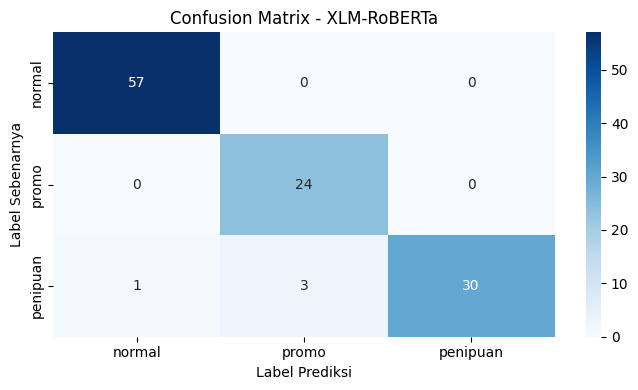

In [37]:
# Membuka fungsi plotting untuk menampilkan grafik confusion matrix prediksi
helper.plot_confusion_matrix(all_labels, all_preds, name = "XLM-RoBERTa")

**Interpretasi:** 

Berdasarkan visualisasi confusion matrix untuk model XLM-RoBERTa, hasil pengujian pada 115 sampel data test menunjukkan tingkat akurasi prediksi yang sangat tinggi dan merata di setiap kelas target. Pada kelas teks normal, model berhasil memprediksi dengan benar sebanyak 56 sampel dan hanya melakukan kekeliruan klasifikasi sebanyak 1 sampel yang terprediksi sebagai promo. Sementara itu, untuk kelas promo, model mencatatkan performa sempurna tanpa celah dengan mengklasifikasikan seluruh 24 sampel secara akurat tanpa ada satu pun data yang meleset ke kategori lain. Pada kelas penipuan, model mampu menebak secara tepat sebanyak 30 sampel, meskipun masih terdapat sedikit bias berupa 3 sampel yang salah terdeteksi sebagai promo dan 1 sampel terdeteksi sebagai teks normal. Hasil ini membuktikan bahwa grafik representasi komputasi XLM-RoBERTa memiliki kapabilitas yang sangat solid dalam membedakan karakteristik teks SMS, khususnya dalam mengisolasi pesan promo dari kategori lainnya.

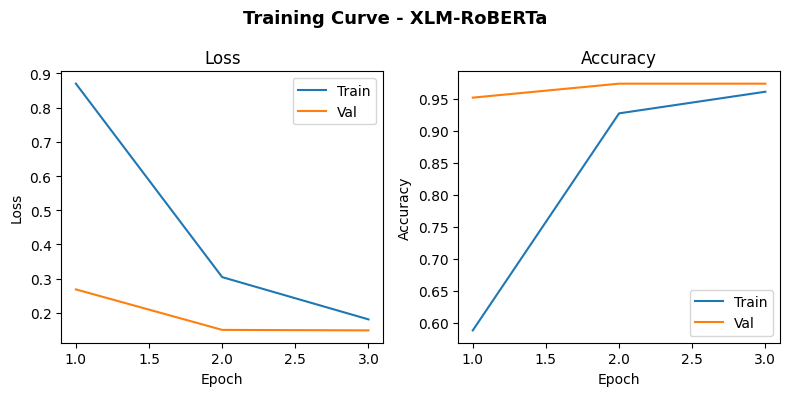

In [38]:
# Membuka fungsi plotting untuk menampilkan grafik kurva dinamika loss dan akurasi model
helper.plot_training_curve(xlm_history, name = "XLM-RoBERTa")

**Interpretasi:** 

Melalui visualisasi training curve, dinamika pergerakan nilai error loss dan tingkat akurasi model XLM-RoBERTa menunjukkan pola perkembangan yang sangat sehat (*good fit*) sepanjang 3 epoch pelatihan yang dijalankan. Pada grafik Loss, nilai error untuk data training mengalami penurunan yang sangat tajam dari angka di atas 0.9 pada epoch pertama hingga menyentuh kisaran 0.2 pada akhir epoch ketiga. Pola penurunan ini diikuti secara konsisten oleh kurva validasi loss yang bergerak turun dari nilai 0.54 hingga mencapai titik optimalnya di angka 0.1347. Sejalan dengan penurunan nilai error tersebut, grafik Accuracy menunjukkan lonjakan performa yang drastis, di mana akurasi data training meningkat pesat dari rentang 65% menuju ke level 95%. Kurva akurasi validasi juga menunjukkan kestabilan yang impresif dengan terus merangkak naik hingga mencapai puncaknya di angka 97.82% pada epoch terakhir. Tidak adanya indikasi divergensi atau pelebaran jarak antara kurva training dan validasi pada kedua grafik ini menegaskan bahwa model terhindar dari masalah overfitting maupun underfitting.